# Model Training, Comparison & Explainability

In [ ]:
import os
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model_table = pd.read_csv("../data/model_table.csv")
print("Model table:", f"{model_table.shape[0]:,}", "rows x", model_table.shape[1], "columns")

Model table: 31,406 rows x 85 columns


### Step 1 — Target and train/test split

The raw salary is strongly right-skewed. So, the models learn **`np.log(salary)`** then after the log transform the distribution is almost symmetric, which suits every model here and stops the few very high salaries from dominating the loss. Predictions are converted back with `np.exp` before any metric is computed, so every number reported below is in RM not log units.

One fixed 80/20 split (`random_state=42`) is created once and will be reused by all models, so the comparison is fair. Every model sees exactly the same training rows and is judged on exactly the same test rows.

In [ ]:
TARGET = "salary_monthly_final"
X = model_table.drop(columns=[TARGET])
y_rm = model_table[TARGET]              # salary in RM (used for evaluation)
y_log = np.log(y_rm)                    # what the models actually learn
print(f"Target skewness: raw RM {y_rm.skew():.2f} -> log {y_log.skew():.2f}")

X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42)
y_test_rm = np.exp(y_test_log)          
print(f"Train: {len(X_train):,} rows | Test: {len(X_test):,} rows")
print(f"Test set median salary: RM{y_test_rm.median():,.0f}")

Target skewness: raw RM 2.76 -> log 0.02
Train: 25,124 rows | Test: 6,282 rows
Test set median salary: RM3,750


### Step 2 — Preprocessing pipeline

All feature encoding lives inside the sklearn pipeline, fitted only on training data:

- `job_title` = TF-IDF (max 800 features, 1–2 word phrases, a term must appear in ≥5 ads). The title is the single most informative field ("senior software engineer" vs "junior clerk").
- `category`, `state_clean`, `type_clean` = one-hot encoding with `handle_unknown="ignore"`, so an unseen value from the dashboard becomes all-zeros instead of crashing.
- The 80 engineered numeric columns from `01_features` (experience, education requirement and skill flags) pass through unchanged.

In [ ]:
CATEGORICAL = ["category", "state_clean", "type_clean"]
NUMERIC = [c for c in X.columns if c not in CATEGORICAL + ["job_title"]]

preprocessor = ColumnTransformer(
    transformers=[
        ("title", TfidfVectorizer(max_features=800, ngram_range=(1, 2), min_df=5), "job_title"),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL),
        ("num", "passthrough", NUMERIC),
    ],
    sparse_threshold=0.0,   
)
print(f"1 text column, {len(CATEGORICAL)} categorical, {len(NUMERIC)} numeric")

probe = clone(preprocessor).fit(X_train)
print("Total features after preprocessing:", len(probe.get_feature_names_out()))

1 text column, 3 categorical, 80 numeric


Total features after preprocessing: 932


### Step 3 — Train and compare the four locked models

Helper functions keep the protocol identical for every model: fit on the training set, predict the test set, convert back to RM, report **MAE, RMSE and R²**. MAE is the headline metric (it reads as "on average the prediction is RM X off"). The winner is the model with the lowest test MAE.

In [ ]:
def make_pipeline(model):
    """Fresh preprocessing + model pipeline (cloned so models never share state)."""
    return Pipeline([("preprocess", clone(preprocessor)), ("model", model)])

def evaluate(name, pipeline):
    """Fit on train, report MAE / RMSE / R2 in RM on the test set."""
    start = time.time()
    pipeline.fit(X_train, y_train_log)
    pred_rm = np.exp(pipeline.predict(X_test))         
    mae = mean_absolute_error(y_test_rm, pred_rm)
    rmse = np.sqrt(mean_squared_error(y_test_rm, pred_rm))
    r2 = r2_score(y_test_rm, pred_rm)
    print(f"{name:22} MAE RM{mae:7,.0f} | RMSE RM{rmse:7,.0f} | "
          f"R2 {r2:.3f} | {time.time() - start:5.0f}s")
    return {"model": name, "MAE_RM": round(mae), "RMSE_RM": round(rmse), "R2": round(r2, 3)}, pipeline

X_sub, X_val, y_sub, y_val = train_test_split(
    X_train, y_train_log, test_size=0.2, random_state=42)
y_val_rm = np.exp(y_val)
best_leaf, best_mae = None, float("inf")
for leaf in [5, 10, 20, 50]:
    pipe = make_pipeline(DecisionTreeRegressor(min_samples_leaf=leaf, random_state=42))
    pipe.fit(X_sub, y_sub)
    mae = mean_absolute_error(y_val_rm, np.exp(pipe.predict(X_val)))
    marker = ""
    if mae < best_mae:
        best_leaf, best_mae = leaf, mae
        marker = "  <- best so far"
    print(f"min_samples_leaf={leaf:3} -> validation MAE RM{mae:,.0f}{marker}")
print(f"\nChosen min_samples_leaf for the decision tree: {best_leaf}")

min_samples_leaf=  5 -> validation MAE RM1,228  <- best so far


min_samples_leaf= 10 -> validation MAE RM1,201  <- best so far


min_samples_leaf= 20 -> validation MAE RM1,184  <- best so far


min_samples_leaf= 50 -> validation MAE RM1,194

Chosen min_samples_leaf for the decision tree: 20


In [ ]:
# The four locked models, all trained on the same split and features.
models = {
    "LinearRegression": LinearRegression(),
    "DecisionTree": DecisionTreeRegressor(min_samples_leaf=best_leaf, random_state=42),
    "RandomForest": RandomForestRegressor(n_estimators=200, min_samples_leaf=3,
                                          n_jobs=-1, random_state=42),
    "HistGradientBoosting": HistGradientBoostingRegressor(random_state=42),
}
results, fitted = [], {}
for name, model in models.items():
    row, pipe = evaluate(name, make_pipeline(model))
    results.append(row)
    fitted[name] = pipe

comparison = pd.DataFrame(results).sort_values("MAE_RM").reset_index(drop=True)
print("\nModel comparison (sorted by test MAE, all metrics in RM):")
print(comparison.to_string(index=False))

winner_name = comparison.iloc[0]["model"]
winner = fitted[winner_name]
print(f"\nWinner (lowest test MAE): {winner_name}")

LinearRegression       MAE RM  1,061 | RMSE RM  1,867 | R2 0.555 |     3s


DecisionTree           MAE RM  1,118 | RMSE RM  1,972 | R2 0.504 |     4s


RandomForest           MAE RM    963 | RMSE RM  1,763 | R2 0.604 |   229s


HistGradientBoosting   MAE RM    983 | RMSE RM  1,777 | R2 0.597 |    12s

Model comparison (sorted by test MAE, all metrics in RM):
               model  MAE_RM  RMSE_RM    R2
        RandomForest     963     1763 0.604
HistGradientBoosting     983     1777 0.597
    LinearRegression    1061     1867 0.555
        DecisionTree    1118     1972 0.504

Winner (lowest test MAE): RandomForest


### Step 4 — Quantile models for the displayed salary range

In [6]:
q_low = make_pipeline(HistGradientBoostingRegressor(
    loss="quantile", quantile=0.25, random_state=42))
q_high = make_pipeline(HistGradientBoostingRegressor(
    loss="quantile", quantile=0.75, random_state=42))
q_low.fit(X_train, y_train_log)
q_high.fit(X_train, y_train_log)

low_rm = np.exp(q_low.predict(X_test))
high_rm = np.exp(q_high.predict(X_test))
point_rm = np.exp(winner.predict(X_test))

coverage = ((y_test_rm >= low_rm) & (y_test_rm <= high_rm)).mean()
print(f"Test salaries inside their predicted [P25, P75] range: {coverage:.1%} (ideal ~50%)")
print(f"Median range width: RM{np.median(high_rm - low_rm):,.0f}")
print(f"Median range: RM{np.median(low_rm):,.0f} - RM{np.median(high_rm):,.0f}")
print(f"Ranges with lower > upper: {(low_rm > high_rm).sum()} of {len(low_rm)}")
inside = ((point_rm >= low_rm) & (point_rm <= high_rm)).mean()
print(f"Point predictions already inside their own range: {inside:.1%} (dashboard clips the rest)")

Test salaries inside their predicted [P25, P75] range: 47.3% (ideal ~50%)
Median range width: RM1,033
Median range: RM3,348 - RM4,370
Ranges with lower > upper: 9 of 6282
Point predictions already inside their own range: 86.9% (dashboard clips the rest)


### Step 5 — Subgroup error analysis

The test-set error is grouped by **category** and by **state** to show where the model is reliable and where it is not. Small groups (some categories/states have only a handful of test rows) will look noisy, their `n_test_rows` column is the health warning.

In [7]:
errors = pd.DataFrame({
    "category": X_test["category"].values,
    "state": X_test["state_clean"].values,
    "abs_error_rm": np.abs(y_test_rm.values - point_rm),
})

def subgroup_table(col):
    g = errors.groupby(col)["abs_error_rm"].agg(["mean", "count"])
    g.columns = ["MAE_RM", "n_test_rows"]
    return g.sort_values("MAE_RM").round(0).astype(int)

cat_mae = subgroup_table("category")
state_mae = subgroup_table("state")
print("Test MAE by category (best to worst):")
print(cat_mae.to_string())
print("\nTest MAE by state (best to worst):")
print(state_mae.to_string())

Test MAE by category (best to worst):
                                        MAE_RM  n_test_rows
category                                                   
Administration & Office Support            541          647
Advertising, Arts & Media                  681           52
Education & Training                       707           80
Marketing & Communications                 722          385
Call Centre & Customer Service             731          239
Accounting                                 789         1174
Manufacturing, Transport & Logistics       800          560
Design & Architecture                      837           99
Farming, Animals & Conservation            889           11
Trades & Services                          960           82
Legal                                      976           21
Science & Technology                       985           39
Human Resources & Recruitment             1000          332
Sales                                     1073          606
Co

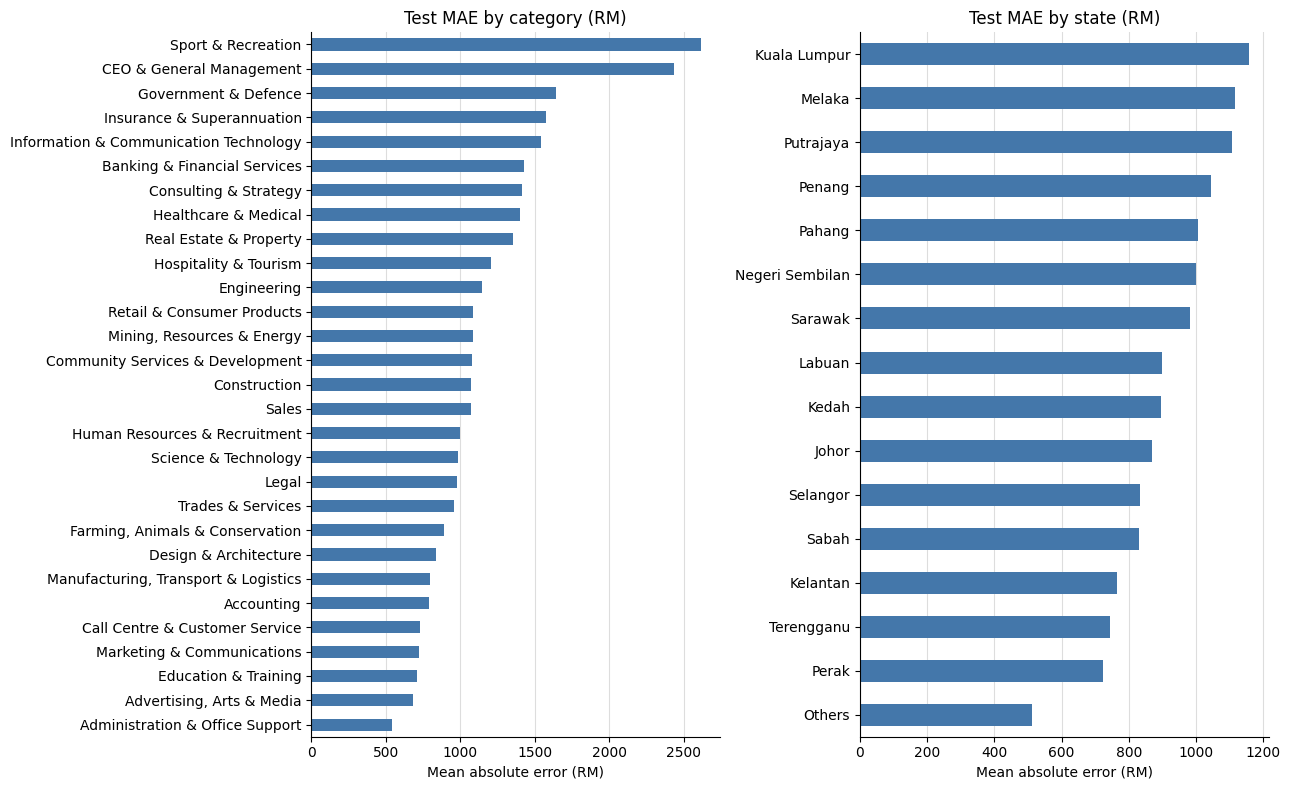

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 8))
for ax, table, label in [(axes[0], cat_mae, "category"), (axes[1], state_mae, "state")]:
    table["MAE_RM"].plot.barh(ax=ax, color="#4477AA")
    ax.set_title(f"Test MAE by {label} (RM)")
    ax.set_xlabel("Mean absolute error (RM)")
    ax.set_ylabel("")
    ax.grid(axis="x", color="#DDDDDD", linewidth=0.8)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### Step 6 — Save the model artifacts

In [ ]:
os.makedirs("../models", exist_ok=True)
skill_lists = joblib.load("../models/skill_lists.joblib")  

artifacts = {
    "salary_pipeline.joblib": winner,
    "quantile_lower_pipeline.joblib": q_low,
    "quantile_upper_pipeline.joblib": q_high,
    "input_options.joblib": {
        "categories": sorted(model_table["category"].unique()),
        "states": sorted(model_table["state_clean"].unique()),
        "types": sorted(model_table["type_clean"].unique()),
        "skills": skill_lists,
    },
}
for fname, obj in artifacts.items():
    path = "../models/" + fname
    joblib.dump(obj, path, compress=3)
    print(f"Saved {path} ({os.path.getsize(path) / 1024:,.0f} KB)")

comparison.to_csv("../models/model_comparison.csv", index=False)
print("Saved ../models/model_comparison.csv")

Saved ../models/salary_pipeline.joblib (39,164 KB)
Saved ../models/quantile_lower_pipeline.joblib (411 KB)
Saved ../models/quantile_upper_pipeline.joblib (409 KB)
Saved ../models/input_options.joblib (2 KB)
Saved ../models/model_comparison.csv


### Step 7 — SHAP explainability on the winning model

`shap.TreeExplainer` computes, for one prediction, how much each feature pushed it up or down. Values are in **log-salary units**; the dashboard converts them into plain-language sentences.

The explainer object is saved so the dashboard can build a per-prediction waterfall without recomputing anything.

Additivity check (must match):
  base + shap : [7.9487 8.4418 7.86  ]
  model output: [7.9487 8.4418 7.86  ]


SHAP cost: 0.17s per row -> explaining 1500 test rows



  4%|=                   | 62/1500 [00:11<04:15]       


  4%|=                   | 66/1500 [00:12<04:20]       


  5%|=                   | 71/1500 [00:13<04:21]       

...


 99%|===================| 1479/1500 [05:26<00:04]       


 99%|===================| 1484/1500 [05:27<00:03]       


 99%|===================| 1489/1500 [05:28<00:02]       


100%|===================| 1495/1500 [05:29<00:01]       

SHAP values computed: (1500, 932) in 330s

Top 10 features by mean |SHAP| (log-salary units):
manager                                            0.1243
experience_years                                   0.0859
assistant                                          0.0427
internship                                         0.0422
state_clean_Kuala Lumpur                           0.0368
edu_level                                          0.0335
executive                                          0.0264
intern                                             0.0248
senior                                             0.0196
category_Information & Communication Technology    0.0181


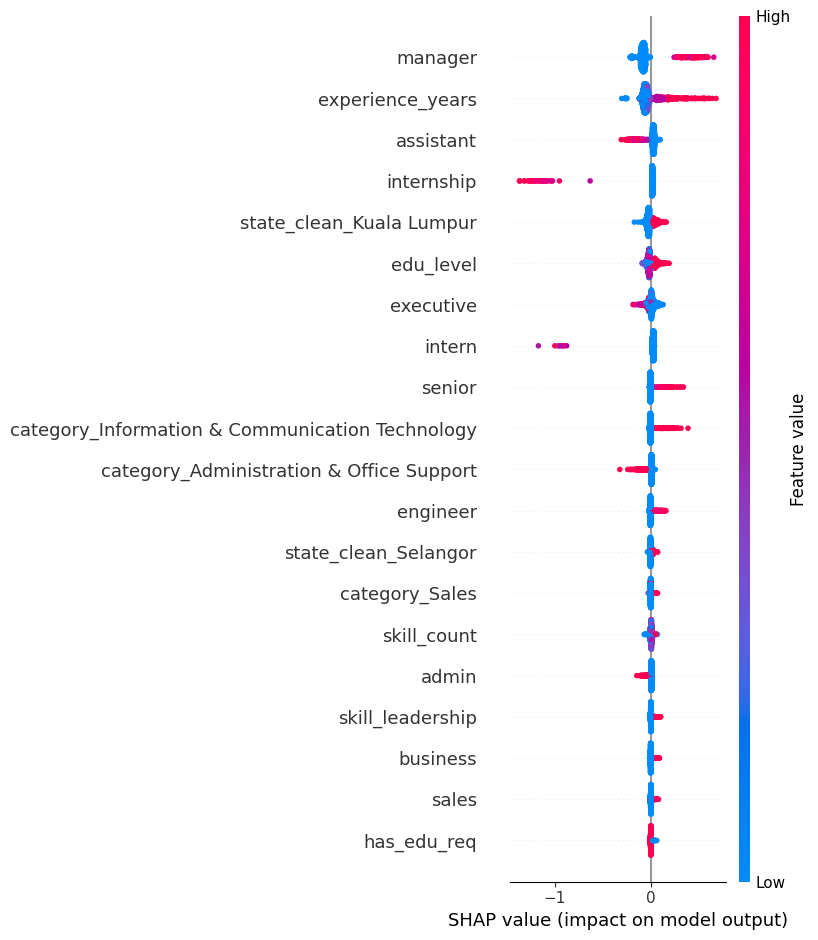

In [ ]:
assert winner_name in {"DecisionTree", "RandomForest", "HistGradientBoosting"}, \
    f"Winner {winner_name} is not tree-based; SHAP approach needs discussing"

# Transform the test set with the winner's own fitted preprocessor
X_test_enc = winner.named_steps["preprocess"].transform(X_test)
feature_names = [n.split("__", 1)[1]
                 for n in winner.named_steps["preprocess"].get_feature_names_out()]

rng_bg = np.random.RandomState(42)
bg_idx = rng_bg.choice(len(X_train), size=100, replace=False)
background = winner.named_steps["preprocess"].transform(X_train.iloc[bg_idx])
explainer = shap.TreeExplainer(winner.named_steps["model"], data=background,
                               feature_perturbation="interventional")

sv_check = explainer.shap_values(X_test_enc[:3])
sums = np.ravel(explainer.expected_value) + sv_check.sum(axis=1)
outs = winner.named_steps["model"].predict(X_test_enc[:3])
print("Additivity check (must match):")
print("  base + shap :", np.round(sums, 4))
print("  model output:", np.round(outs, 4))

rng = np.random.RandomState(42)
order = rng.permutation(X_test_enc.shape[0])
t0 = time.time()
_ = explainer.shap_values(X_test_enc[order[:10]])
per_row = (time.time() - t0) / 10
n_sample = int(np.clip(600 / max(per_row, 1e-6), 150, 1500))
print(f"SHAP cost: {per_row:.2f}s per row -> explaining {n_sample} test rows")

idx = order[:n_sample]
t0 = time.time()
shap_values = explainer.shap_values(X_test_enc[idx])
print(f"SHAP values computed: {shap_values.shape} in {time.time() - t0:,.0f}s")

top10 = (pd.Series(np.abs(shap_values).mean(axis=0), index=feature_names)
         .sort_values(ascending=False).head(10))
print("\nTop 10 features by mean |SHAP| (log-salary units):")
print(top10.round(4).to_string())

shap.summary_plot(shap_values, X_test_enc[idx],
                  feature_names=feature_names, max_display=20)

In [ ]:
# Save the explainability artifacts, then reload-check the main pipeline
joblib.dump(explainer, "../models/shap_explainer.joblib", compress=3)
joblib.dump(feature_names, "../models/feature_names.joblib", compress=3)
for p in ["../models/shap_explainer.joblib", "../models/feature_names.joblib"]:
    print(f"Saved {p} ({os.path.getsize(p) / 1024:,.0f} KB)")

reloaded = joblib.load("../models/salary_pipeline.joblib")
pred = np.exp(reloaded.predict(X_test.iloc[[0]]))[0]
print(f"\nReload check -> one test row: predicted RM{pred:,.0f}, "
      f"actual RM{y_test_rm.iloc[0]:,.0f}")
print("Modelling complete.")

Saved ../models/shap_explainer.joblib (45,410 KB)
Saved ../models/feature_names.joblib (5 KB)



Reload check -> one test row: predicted RM2,832, actual RM2,300
Modelling complete.
